# DBSCAN 实验

## 3.1 DBSCAN 简介（主要思想与参数）

### 什么是 DBSCAN？

DBSCAN 是一种基于密度（Density-Based）的聚类算法。与 K-Means 不同，DBSCAN 不需要提前指定聚类数量，而是根据数据点之间的密度分布自动形成聚类，并能够识别噪声点（离群点）。

DBSCAN 特别适用于:

- 任意形状的数据聚类
- 含有噪声的数据集
- 无监督学习任务

### DBSCAN 的核心思想

#### DBSCAN 的基本思想是：

如果某个数据点在指定半径范围内拥有足够多的邻居，那么该点位于一个高密度区域，可以形成聚类。

DBSCAN 将数据点分为三类：

（1）核心点（Core Point）

在一定半径范围内拥有足够数量邻居的数据点。

（2）边界点（Border Point）

本身邻居数量不足，但位于某个核心点附近的数据点。

（3）噪声点（Noise Point）

既不是核心点，也无法归属于任何聚类的数据点。

### DBSCAN 的重要参数
（1）eps

eps 表示邻域半径（Neighborhood Radius）。

即：在该距离范围内的数据点会被视为邻居。

eps 较小时：
- 聚类条件严格
- 更容易产生噪声点
- 聚类数量可能增多
eps 较大时：
- 聚类更容易合并
- 不同类别可能被错误融合
（2）min_samples

表示形成核心点所需的最少邻居数量。

min_samples 较小时：
- 更容易形成聚类
- 对噪声敏感
min_samples 较大时：
- 聚类更加稳定
- 更多点可能被视为噪声

#### DBSCAN 的优点
- 不需要提前指定聚类数量
- 能自动识别离群点
- 能处理非规则形状聚类
#### DBSCAN 的缺点
- 对参数较敏感
- 高维数据效果可能下降
- 不适用于密度差异较大的数据

### 🌱 课前准备




In [32]:
pip install numpy pandas matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [33]:
pip install --upgrade numexpr

## 3.2 DBSCAN 聚类与可视化
### 实验目的

本实验中：

- 使用 Iris 鸢尾花数据集
- 使用 PCA 降维至二维
- 使用 DBSCAN 进行聚类
- 在散点图中标记核心点
  实验流程  
(1) 导入 Iris 数据集  
(2)数据标准化  
(3)PCA 降维  
(4)DBSCAN 聚类  
(5)聚类结果可视化  
(6标记核心点  

In [34]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

#### 加载数据集与数据预处理

In [35]:
# ================================
# Step 1: 导入数据集
# ================================

iris = load_iris()
X = iris.data

# ================================
# Step 2: 数据标准化
# ================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### PCA降维

In [36]:
# ================================
# Step 3: PCA降维
# ================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


#### 聚类与统计核心点，噪声点

In [37]:
# ================================
# Step 4: DBSCAN聚类
# ================================

dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

labels = dbscan.fit_predict(X_pca)

# ================================
# Step 5: 获取核心点
# ================================

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
# ====================================
# Core points and noise points analysis
# ====================================

# 核心点数量
n_core = len(dbscan.core_sample_indices_)

# 噪声点数量
n_noise = list(labels).count(-1)

print("Number of core points:", n_core)
print("Number of noise points:", n_noise)

Number of core points: 136
Number of noise points: 6


#### 结果可视化

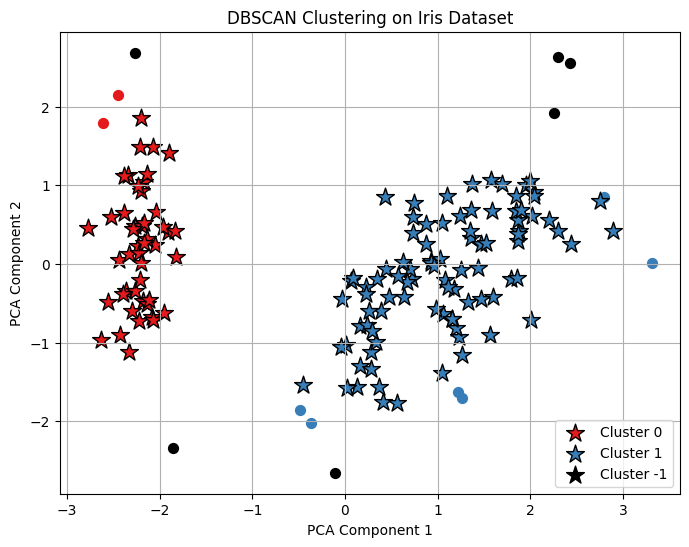

In [38]:
# ================================
# Step 6: 聚类结果可视化
# ================================

unique_labels = set(labels)

plt.figure(figsize=(8,6))

for label in unique_labels:

    # 不同聚类使用不同颜色
    if label == -1:
        color = 'black'
        label_name = 'Noise'
    else:
        color = plt.cm.Set1(label)

    class_member_mask = (labels == label)

    # 绘制普通点
    xy = X_pca[class_member_mask & ~core_samples_mask]

    plt.scatter(
        xy[:,0],
        xy[:,1],
        s=50,
        c=[color],
        marker='o'
    )

    # 绘制核心点
    xy_core = X_pca[class_member_mask & core_samples_mask]

    plt.scatter(
        xy_core[:,0],
        xy_core[:,1],
        s=180,
        c=[color],
        marker='*',
        edgecolors='k',
        label=f'Cluster {label}'
    )

# 图像设置
plt.title("DBSCAN Clustering on Iris Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)

plt.show()

#### 实验结果分析
PCA 散点图

由于原始 Iris 数据具有 4 个特征，因此使用 PCA 将数据降至二维，方便可视化展示。

PCA 的作用是：

保留主要信息
降低维度
方便观察聚类效果
聚类结果分析

DBSCAN 会自动根据样本密度形成聚类。

在图中：

- 不同颜色表示不同聚类
- 黑色点表示噪声点
- 星号表示核心点
  
##### 核心点分析：
核心点使用较大的 “*” 星形标记表示。
这些点位于高密度区域，是聚类扩展的重要基础。

##### 噪声点分析：
标签值为 -1 的点被视为噪声点。

这些样本：
不属于任何聚类
通常为离群数据

## 3.3 不同参数下的 DBSCAN 实验
### 实验目的

本部分研究：
eps和min_samples对 DBSCAN 聚类效果的影响。

实验使用：
DBI（Davies-Bouldin Index）评价聚类质量，并与：K-Means（KM）进行比较。

### 什么是 DBI？

DBI（Davies-Bouldin Index）用于评价聚类质量。

DBI 的含义
DBI 越小：

- 类内距离更小
- 类间距离更大
- 聚类效果更好
  
DBI 越大：
- 说明聚类效果较差。

### DBSCAN 参数实验

In [39]:
# 导入库
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### 数据的加载与预处理

In [40]:
# 导入数据集
iris = load_iris()
X = iris.data

# 数据标准化
X_scaled = StandardScaler().fit_transform(X)


#### PCA降维

In [41]:
# PCA降维
X_pca = PCA(n_components=2).fit_transform(X_scaled)

#### 参数测试与对比实验

In [42]:
# ====================================
# DBSCAN 参数测试 + K-Means 对比实验
# ====================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import davies_bouldin_score

# 设置DBSCAN参数范围
eps_list = [0.3, 0.5, 0.7, 0.9]
min_samples_list = [3, 5, 7, 10]

results = []

# ====================================
# DBSCAN 参数测试
# ====================================

for eps in eps_list:

    for min_samples in min_samples_list:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_pca)

        unique_labels = set(labels)

        # 计算聚类数量，不把噪声点 -1 当作正常聚类
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        # 计算噪声点数量
        n_noise = list(labels).count(-1)

        # 至少需要2个聚类，DBI才有意义
        if n_clusters >= 2:

            dbi = davies_bouldin_score(
                X_pca,
                labels
            )

            results.append([
                eps,
                min_samples,
                n_clusters,
                n_noise,
                dbi
            ])

# ====================================
# 输出 DBSCAN 参数测试结果
# ====================================

results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'n_clusters',
        'n_noise',
        'DBI'
    ]
)

print("DBSCAN Parameter Test Results:")
print(results_df)

# ====================================
# 找到最优 DBSCAN 结果
# ====================================

best_dbscan = results_df.loc[
    results_df['DBI'].idxmin()
]

print("\nBest DBSCAN Result:")
print(best_dbscan)

# ====================================
# K-Means 对比实验
# ====================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_pca)

kmeans_dbi = davies_bouldin_score(
    X_pca,
    kmeans_labels
)

print("\nK-Means Result:")
print("K-Means DBI:", kmeans_dbi)

# ====================================
# DBSCAN 与 K-Means 对比总结
# ====================================

comparison_df = pd.DataFrame({
    'Method': ['Best DBSCAN', 'K-Means'],
    'DBI': [
        best_dbscan['DBI'],
        kmeans_dbi
    ]
})

print("\nComparison between DBSCAN and K-Means:")
print(comparison_df)

DBSCAN Parameter Test Results:
    eps  min_samples  n_clusters  n_noise       DBI
0   0.3            3           5       19  2.398967
1   0.3            5           5       33  2.517318
2   0.3            7           4       61  2.913187
3   0.3           10           3      108  0.848442
4   0.5            3           2        7  3.255860
5   0.5            5           2       12  5.532100
6   0.5            7           2       15  4.234500
7   0.5           10           2       20  3.932566
8   0.7            3           3        1  0.444207
9   0.7            5           2        5  1.763765
10  0.7            7           2        8  2.613394
11  0.7           10           2        8  2.613394
12  0.9            3           3        1  0.444207
13  0.9            5           2        4  1.864588
14  0.9            7           2        4  1.864588
15  0.9           10           2        6  4.136225

Best DBSCAN Result:
eps            0.700000
min_samples    3.000000
n_clusters     3

### 不同参数的影响 可视化

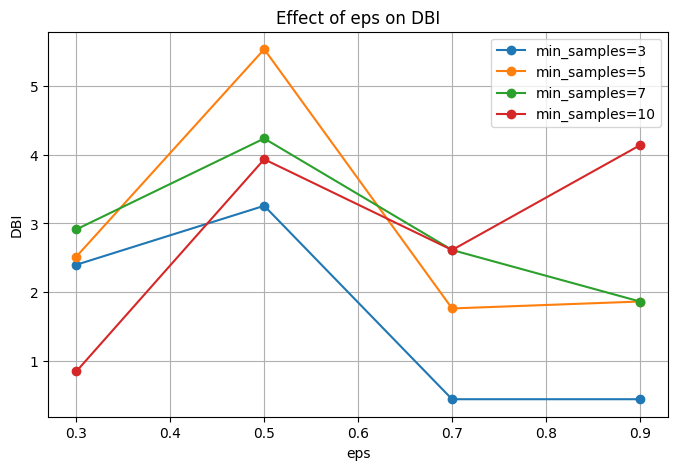

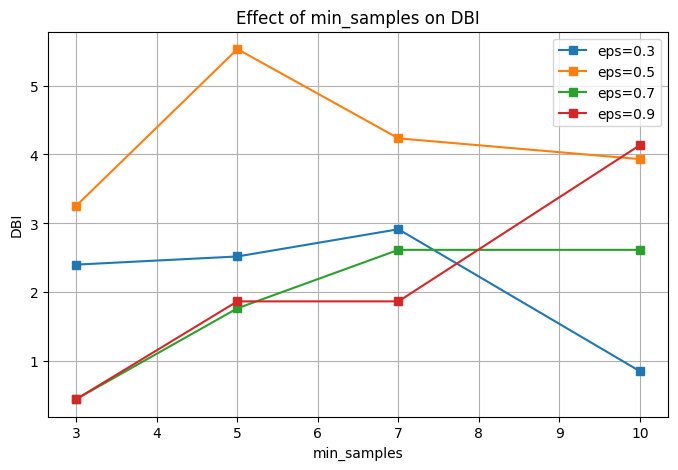

In [43]:
# ====================================
# DBSCAN 参数结果可视化：eps 对 DBI 的影响
# ====================================

plt.figure(figsize=(8,5))

for min_samples in min_samples_list:

    subset = results_df[
        results_df['min_samples'] == min_samples
    ]

    plt.plot(
        subset['eps'],
        subset['DBI'],
        marker='o',
        label=f"min_samples={min_samples}"
    )

plt.title("Effect of eps on DBI")
plt.xlabel("eps")
plt.ylabel("DBI")
plt.legend()
plt.grid(True)
plt.show()
# ====================================
# DBSCAN 参数结果可视化：min_samples 对 DBI 的影响
# ====================================

plt.figure(figsize=(8,5))

for eps in eps_list:

    subset = results_df[
        results_df['eps'] == eps
    ]

    plt.plot(
        subset['min_samples'],
        subset['DBI'],
        marker='s',
        label=f"eps={eps}"
    )

plt.title("Effect of min_samples on DBI")
plt.xlabel("min_samples")
plt.ylabel("DBI")
plt.legend()
plt.grid(True)
plt.show()

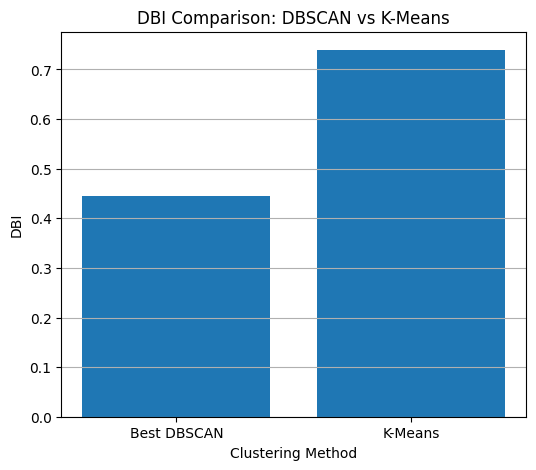

In [44]:
# ====================================
# DBSCAN 与 K-Means 的 DBI 对比图
# ====================================

plt.figure(figsize=(6,5))

plt.bar(
    comparison_df['Method'],
    comparison_df['DBI']
)

plt.title("DBI Comparison: DBSCAN vs K-Means")
plt.xlabel("Clustering Method")
plt.ylabel("DBI")

plt.grid(axis='y')
plt.show()

### 实验分析
eps 对聚类的影响

eps 较小时：
- 聚类更加严格
- 容易产生大量噪声点
- 聚类数量增多
 
eps 较大时：
- 聚类容易融合
- 不同类别可能被合并

min_samples 对聚类的影响

min_samples 较小时：
- 更容易形成聚类
- 对噪声敏感
  
min_samples 较大时：
- 聚类更加稳定
- 部分样本会被判定为噪声


#### 与 K-Means 的比较
DBSCAN
优点：

能处理非规则形状；
能自动识别噪声点；
不需要指定聚类数量

缺点：

参数敏感；
高维效果可能下降

K-Means
优点：

计算速度快；
适用于规则球状聚类

缺点：

需要提前指定聚类数量；
无法识别噪声点

### 本实验结果

对于 Iris 数据集：

由于其数据分布较规则，因此 K-Means 可能获得更低的 DBI 值。而DBSCAN 在不同参数组合下的 DBI 差异较大，说明 eps 和 min_samples 对聚类结果影响明显。其中 DBI 最小的参数组合代表本次实验中的最优 DBSCAN 设置。与 K-Means 相比，K-Means 在 Iris 这种分布较规则的数据集上通常表现更稳定，而 DBSCAN 的优势主要体现在能够识别噪声点，并适合处理非规则形状的数据。



#### 实验表明：
DBSCAN 能有效识别数据中的密度结构，并具有较好的噪声处理能力，但聚类效果对参数选择较为敏感。